In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

In [9]:
data = pd.read_csv('googleStockPrice.csv')
data.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [10]:
data['Volume'] = data['Volume'].str.replace(',', '').astype(float)

In [11]:
prices = data[['Open']].values

# Scale data
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

In [12]:
# creat sequences
X = []  #input (past 60 days)
y = []  #output(next day)

for i in range(60, len(prices_scaled)):
    X.append(prices_scaled[i-60:i])   # 60 timesteps , take last 60 days
    y.append(prices_scaled[i])

X = np.array(X)
y = np.array(y)

In [13]:
print("Shape before:", X.shape)

Shape before: (1198, 60, 1)


In [14]:
# Model
model = Sequential()
model.add(Input(shape=(60,1)))   #Input = 60 days × 1 value per day
model.add(LSTM(50))   #50 neurons, remembers past data
model.add(Dense(1))

In [15]:
model.compile(optimizer="adam", loss="mean_squared_error") #Uses adam to update weights and mean_squared_error (MSE) to measure how far the prediction is from the actual price.

In [16]:
model.fit(X, y, epochs=5, batch_size=32)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0582
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0027
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0013
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0012
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0012


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step  


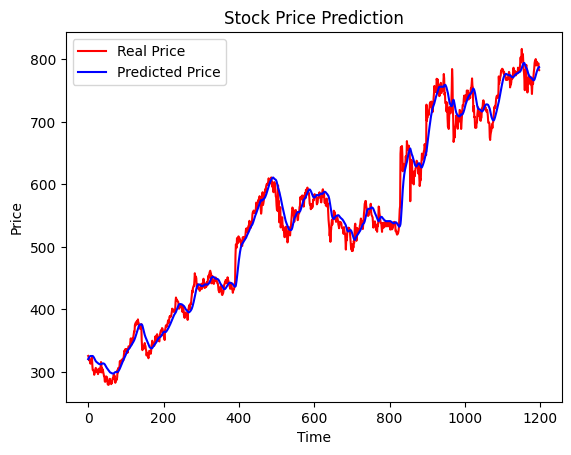

In [17]:
# Predict on training data (for visualization)
predicted = model.predict(X)

# Convert back to original scale
predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y)

# Plot graph
import matplotlib.pyplot as plt

plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [18]:
# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(real, predicted))
mae = mean_absolute_error(real, predicted)
r2 = r2_score(real, predicted)  #1-perfect, 0-bad

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 18.58272230204869
MAE: 13.455102106008386
R2 Score: 0.9839313563288556


❓20. What is RMSE?

👉 Root Mean Squared Error
Measures prediction error magnitude.

❓21. What is MAE?

👉 Mean Absolute Error
Average absolute difference between real and predicted values.

❓22. What is R² score?

👉 Indicates how well model explains data:

1 → perfect
0 → poor
❓23. What does the graph show?

👉 Comparison between:

Actual prices (red)
Predicted prices (blue)
❓24. How do you know model is good from graph?

👉 If predicted line closely follows actual line.

❓25. What is overfitting in this context?

👉 Model memorizes training data but fails on new data.
❓30. Difference between RNN and LSTM?
RNN	LSTM
Short memory	Long memory
Vanishing gradient	Solves it
Simple	More complex
❓31. What is vanishing gradient problem?

👉 Gradients become very small → model stops learning long-term dependencies.

❓32. Why LSTM is suitable for time series?

👉 Because it remembers previous time steps, which are important in sequential data.